In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('netflix_titles.csv')

# Menampilkan 5 data pertama
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
print("\nInformasi Dataset")
print(df.info())

print("\nJumlah Baris dan Kolom")
print(df.shape)


Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Jumlah Baris dan Kolom
(8807, 12)


In [6]:
# Mengecek missing values
print("\nMissing Values")
print(df.isnull().sum())

# Menghapus missing values pada kolom penting
# year release biasanya bernama release_year
# type berisi Movie atau TV Show

df = df.dropna(subset=['release_year', 'type'])

# Menghapus data duplikat
print("\nJumlah Data Sebelum Menghapus Duplicate:")
print(df.shape)

df = df.drop_duplicates()

print("\nJumlah Data Setelah Menghapus Duplicate:")
print(df.shape)


Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Jumlah Data Sebelum Menghapus Duplicate:
(8807, 12)

Jumlah Data Setelah Menghapus Duplicate:
(8807, 12)


In [7]:
# Mengambil hanya kolom yang diperlukan
netflix = df[['type', 'release_year']]

# Menghitung jumlah produksi per tahun
produksi_tahun = netflix.groupby('release_year').size()

print("\nJumlah Produksi per Tahun")
print(produksi_tahun)


Jumlah Produksi per Tahun
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Length: 74, dtype: int64


In [8]:
print("\nSTATISTIK DESKRIPTIF")
print(produksi_tahun.describe())


STATISTIK DESKRIPTIF
count      74.000000
mean      119.013514
std       266.982042
min         1.000000
25%         3.000000
50%        12.500000
75%        58.500000
max      1147.000000
dtype: float64


In [9]:
mean_produksi = produksi_tahun.mean()
median_produksi = produksi_tahun.median()
modus_produksi = produksi_tahun.mode()

print("\nUKURAN TENDENSI SENTRAL")
print(f"Mean Produksi : {mean_produksi}")
print(f"Median Produksi : {median_produksi}")
print(f"Modus Produksi :")
print(modus_produksi)


UKURAN TENDENSI SENTRAL
Mean Produksi : 119.01351351351352
Median Produksi : 12.5
Modus Produksi :
0    2
dtype: int64


In [8]:
range_produksi = produksi_tahun.max() - produksi_tahun.min()
varians_produksi = produksi_tahun.var()
std_produksi = produksi_tahun.std()

print("\nVARIABILITAS")
print(f"Range : {range_produksi}")
print(f"Varians : {varians_produksi}")
print(f"Standar Deviasi : {std_produksi}")


VARIABILITAS
Range : 1146
Varians : 71279.41077378749
Standar Deviasi : 266.9820420436316


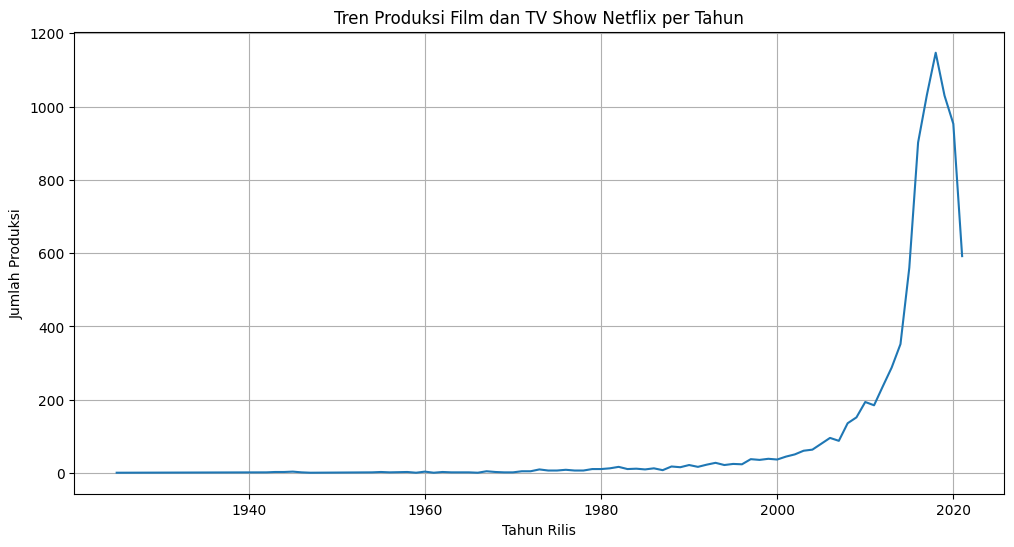

In [9]:
plt.figure(figsize=(12,6))
plt.plot(produksi_tahun.index, produksi_tahun.values)
plt.title('Tren Produksi Film dan TV Show Netflix per Tahun')
plt.xlabel('Tahun Rilis')
plt.ylabel('Jumlah Produksi')
plt.grid(True)
plt.show()

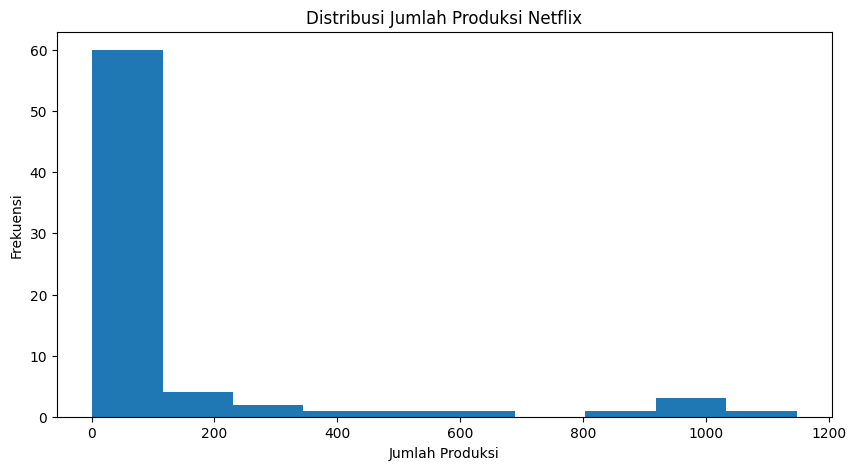

In [10]:
plt.figure(figsize=(10,5))
plt.hist(produksi_tahun.values, bins=10)
plt.title('Distribusi Jumlah Produksi Netflix')
plt.xlabel('Jumlah Produksi')
plt.ylabel('Frekuensi')
plt.show()

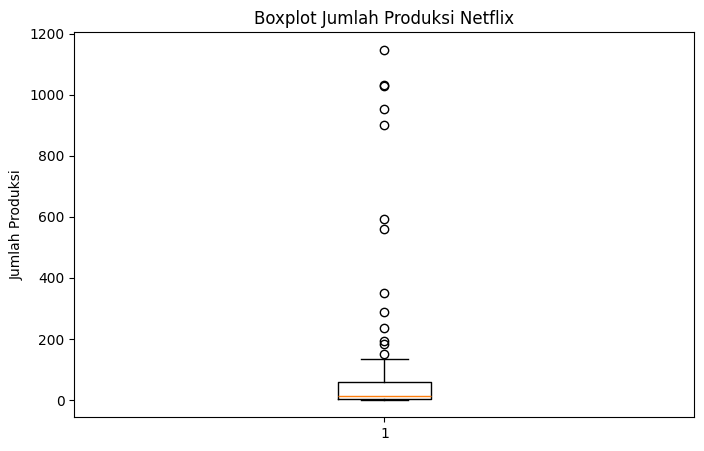

In [11]:
plt.figure(figsize=(8,5))
plt.boxplot(produksi_tahun.values)
plt.title('Boxplot Jumlah Produksi Netflix')
plt.ylabel('Jumlah Produksi')
plt.show()


Jumlah Movie dan TV Show
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


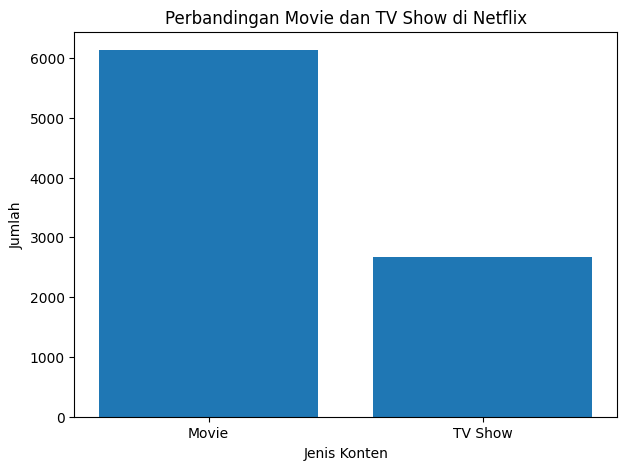

In [12]:
jenis_konten = netflix['type'].value_counts()

print("\nJumlah Movie dan TV Show")
print(jenis_konten)

# Visualisasi tambahan
plt.figure(figsize=(7,5))
plt.bar(jenis_konten.index, jenis_konten.values)
plt.title('Perbandingan Movie dan TV Show di Netflix')
plt.xlabel('Jenis Konten')
plt.ylabel('Jumlah')
plt.show()

In [13]:
print("\nKESIMPULAN")
print("1. Produksi konten Netflix mengalami peningkatan dari tahun ke tahun.")
print("2. Movie memiliki jumlah lebih banyak dibanding TV Show.")
print("3. Variabilitas data menunjukkan adanya perbedaan produksi yang cukup besar pada beberapa tahun tertentu.")


KESIMPULAN
1. Produksi konten Netflix mengalami peningkatan dari tahun ke tahun.
2. Movie memiliki jumlah lebih banyak dibanding TV Show.
3. Variabilitas data menunjukkan adanya perbedaan produksi yang cukup besar pada beberapa tahun tertentu.
